# EDA - PNAD COVID-19

Análise Exploratória de Dados do Tech Challenge 3

**Fonte:** IBGE - PNAD COVID-19 (Setembro a Novembro/2020)

**Requisito:** Análise de 3 meses conforme enunciado oficial

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import awswrangler as wr
from dotenv import load_dotenv
import os

load_dotenv()

# Configurações de visualização
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

## 1. Carregamento dos Dados Gold

**IMPORTANTE:** Filtramos apenas os meses 9, 10 e 11 (Set-Nov/2020) conforme requisito
do Tech Challenge de utilizar 3 meses de dados.

In [2]:
# Configurações AWS
database = "pnad_covid_db"

# Meses permitidos conforme requisito (3 meses: Setembro, Outubro, Novembro)
MESES_ANALISE = [9, 10, 11]

# Carregar tabelas Gold via Athena - FILTRANDO apenas os 3 meses requeridos
df_evolucao = wr.athena.read_sql_query(
    f"SELECT * FROM gold_evolucao_nacional WHERE mes IN ({','.join(map(str, MESES_ANALISE))}) ORDER BY mes",
    database=database
)

df_sintomas_uf = wr.athena.read_sql_query(
    f"SELECT * FROM gold_sintomas_uf_mes WHERE mes IN ({','.join(map(str, MESES_ANALISE))})",
    database=database
)

df_trabalho = wr.athena.read_sql_query(
    f"SELECT * FROM gold_trabalho_regiao_mes WHERE mes IN ({','.join(map(str, MESES_ANALISE))})",
    database=database
)

# Tabelas sem coluna mes - agregam todos os dados disponíveis
# Estas são recalculadas pelo ETL que já filtra os meses corretos
df_testes = wr.athena.read_sql_query(
    "SELECT * FROM gold_testes_uf",
    database=database
)

df_perfil = wr.athena.read_sql_query(
    "SELECT * FROM gold_perfil_sintomaticos",
    database=database
)

In [3]:
print("Dimensões das tabelas Gold:")
print(f"  - Evolução Nacional: {df_evolucao.shape}")
print(f"  - Sintomas por UF/Mês: {df_sintomas_uf.shape}")
print(f"  - Trabalho por Região: {df_trabalho.shape}")
print(f"  - Testes por UF: {df_testes.shape}")
print(f"  - Perfil Sintomáticos: {df_perfil.shape}")

# Verificar que estamos usando apenas os 3 meses corretos
print(f"\n✓ Meses na análise: {sorted(df_evolucao['mes'].unique())}")
assert set(df_evolucao['mes'].unique()) == set(MESES_ANALISE), \
    f"ERRO: Esperado meses {MESES_ANALISE}, encontrado {sorted(df_evolucao['mes'].unique())}"
print(f"✓ Conformidade com requisito de 3 meses: OK")

Dimensões das tabelas Gold:
  - Evolução Nacional: (3, 10)
  - Sintomas por UF/Mês: (81, 16)
  - Trabalho por Região: (15, 7)
  - Testes por UF: (27, 10)
  - Perfil Sintomáticos: (12, 9)

✓ Meses na análise: [np.int32(9), np.int32(10), np.int32(11)]
✓ Conformidade com requisito de 3 meses: OK


## 2. Evolução Temporal

Análise da evolução dos indicadores COVID ao longo dos 3 meses de referência.

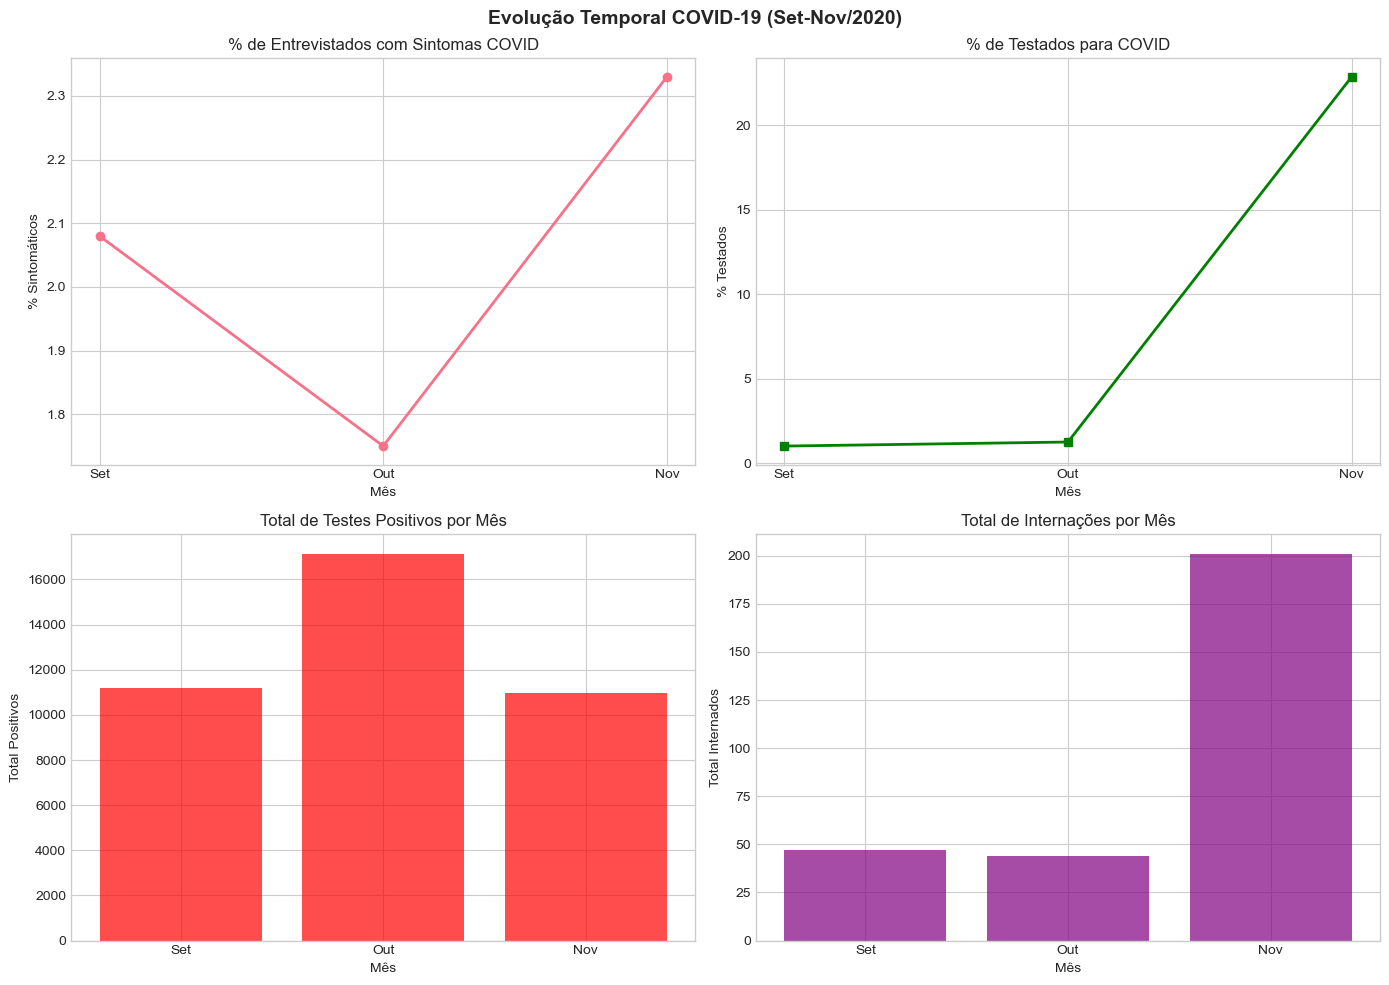

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Evolução Temporal COVID-19 (Set-Nov/2020)', fontsize=14, fontweight='bold')

# Mapeamento de meses para nomes
mes_nome = {9: 'Set', 10: 'Out', 11: 'Nov'}
meses_labels = [mes_nome.get(m, str(m)) for m in df_evolucao['mes']]

# Sintomáticos ao longo do tempo
ax1 = axes[0, 0]
ax1.plot(df_evolucao['mes'], df_evolucao['pct_sintomaticos'], marker='o', linewidth=2)
ax1.set_xlabel('Mês')
ax1.set_ylabel('% Sintomáticos')
ax1.set_title('% de Entrevistados com Sintomas COVID')
ax1.set_xticks(df_evolucao['mes'])
ax1.set_xticklabels(meses_labels)

# Testados ao longo do tempo
ax2 = axes[0, 1]
ax2.plot(df_evolucao['mes'], df_evolucao['pct_testados'], marker='s', linewidth=2, color='green')
ax2.set_xlabel('Mês')
ax2.set_ylabel('% Testados')
ax2.set_title('% de Testados para COVID')
ax2.set_xticks(df_evolucao['mes'])
ax2.set_xticklabels(meses_labels)

# Total de positivos
ax3 = axes[1, 0]
ax3.bar(df_evolucao['mes'], df_evolucao['total_positivos'], color='red', alpha=0.7)
ax3.set_xlabel('Mês')
ax3.set_ylabel('Total Positivos')
ax3.set_title('Total de Testes Positivos por Mês')
ax3.set_xticks(df_evolucao['mes'])
ax3.set_xticklabels(meses_labels)

# Internados
ax4 = axes[1, 1]
ax4.bar(df_evolucao['mes'], df_evolucao['total_internados'], color='purple', alpha=0.7)
ax4.set_xlabel('Mês')
ax4.set_ylabel('Total Internados')
ax4.set_title('Total de Internações por Mês')
ax4.set_xticks(df_evolucao['mes'])
ax4.set_xticklabels(meses_labels)

plt.tight_layout()
plt.savefig('../reports/01_evolucao_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Distribuição Geográfica

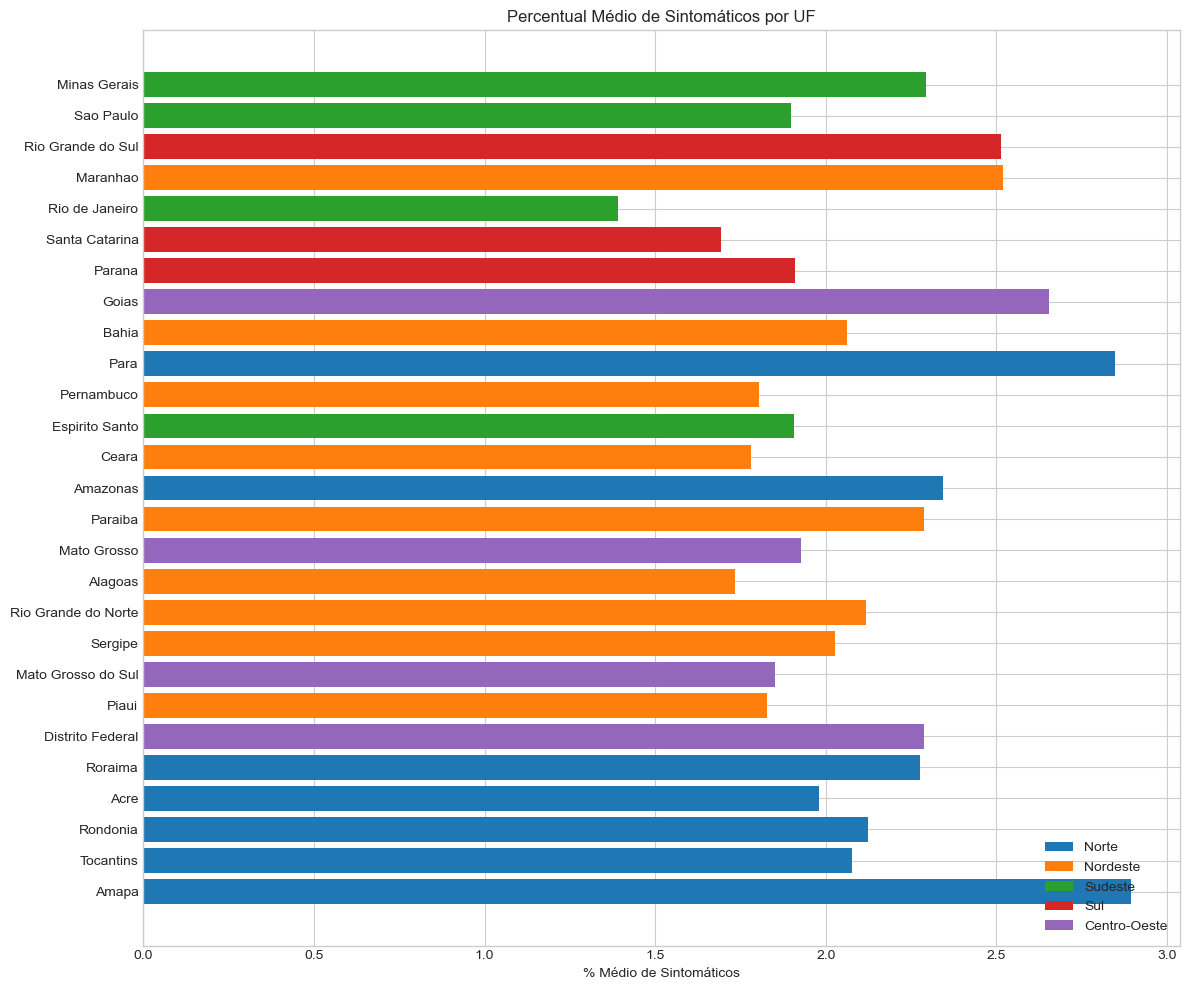

In [5]:
# Agregar por UF
sintomas_uf_total = df_sintomas_uf.groupby(['uf_nome', 'regiao']).agg({
    'total_com_sintomas_covid': 'sum',
    'total_entrevistados': 'sum',
    'pct_sintomas_covid': 'mean'
}).reset_index().sort_values('total_com_sintomas_covid', ascending=True)

fig, ax = plt.subplots(figsize=(12, 10))
colors = sintomas_uf_total['regiao'].map({
    'Norte': '#1f77b4',
    'Nordeste': '#ff7f0e',
    'Sudeste': '#2ca02c',
    'Sul': '#d62728',
    'Centro-Oeste': '#9467bd'
})
ax.barh(sintomas_uf_total['uf_nome'], sintomas_uf_total['pct_sintomas_covid'], color=colors)
ax.set_xlabel('% Médio de Sintomáticos')
ax.set_title('Percentual Médio de Sintomáticos por UF')

# Legenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1f77b4', label='Norte'),
    Patch(facecolor='#ff7f0e', label='Nordeste'),
    Patch(facecolor='#2ca02c', label='Sudeste'),
    Patch(facecolor='#d62728', label='Sul'),
    Patch(facecolor='#9467bd', label='Centro-Oeste')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('../reports/02_sintomas_por_uf.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Impacto no Trabalho

Análise do impacto da pandemia no afastamento do trabalho por região.

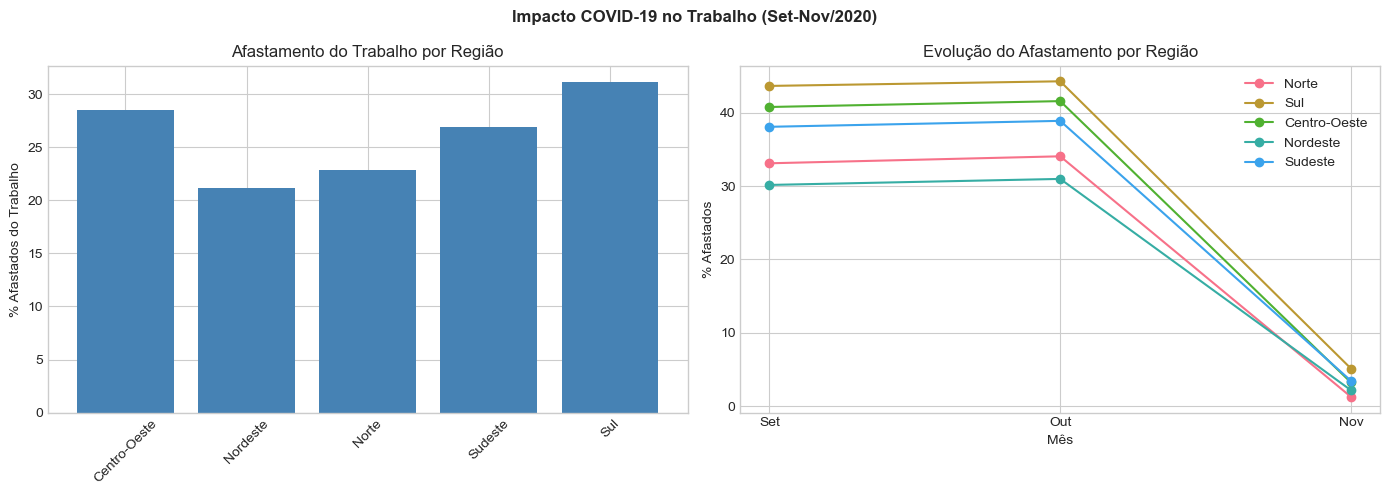

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Impacto COVID-19 no Trabalho (Set-Nov/2020)', fontsize=12, fontweight='bold')

# Afastamentos por região
trabalho_regiao_total = df_trabalho.groupby('regiao').agg({
    'total_afastados': 'sum',
    'total_entrevistados': 'sum'
}).reset_index()
trabalho_regiao_total['pct_afastados'] = (
    trabalho_regiao_total['total_afastados'] / trabalho_regiao_total['total_entrevistados'] * 100
)

ax1 = axes[0]
ax1.bar(trabalho_regiao_total['regiao'], trabalho_regiao_total['pct_afastados'], color='steelblue')
ax1.set_ylabel('% Afastados do Trabalho')
ax1.set_title('Afastamento do Trabalho por Região')
ax1.tick_params(axis='x', rotation=45)

# Evolução temporal por região
ax2 = axes[1]
for regiao in df_trabalho['regiao'].unique():
    dados_regiao = df_trabalho[df_trabalho['regiao'] == regiao].sort_values('mes')
    ax2.plot(dados_regiao['mes'], dados_regiao['pct_afastados'], marker='o', label=regiao)
ax2.set_xlabel('Mês')
ax2.set_ylabel('% Afastados')
ax2.set_title('Evolução do Afastamento por Região')
ax2.set_xticks(MESES_ANALISE)
ax2.set_xticklabels(['Set', 'Out', 'Nov'])
ax2.legend()

plt.tight_layout()
plt.savefig('../reports/03_impacto_trabalho.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Perfil Demográfico dos Sintomáticos

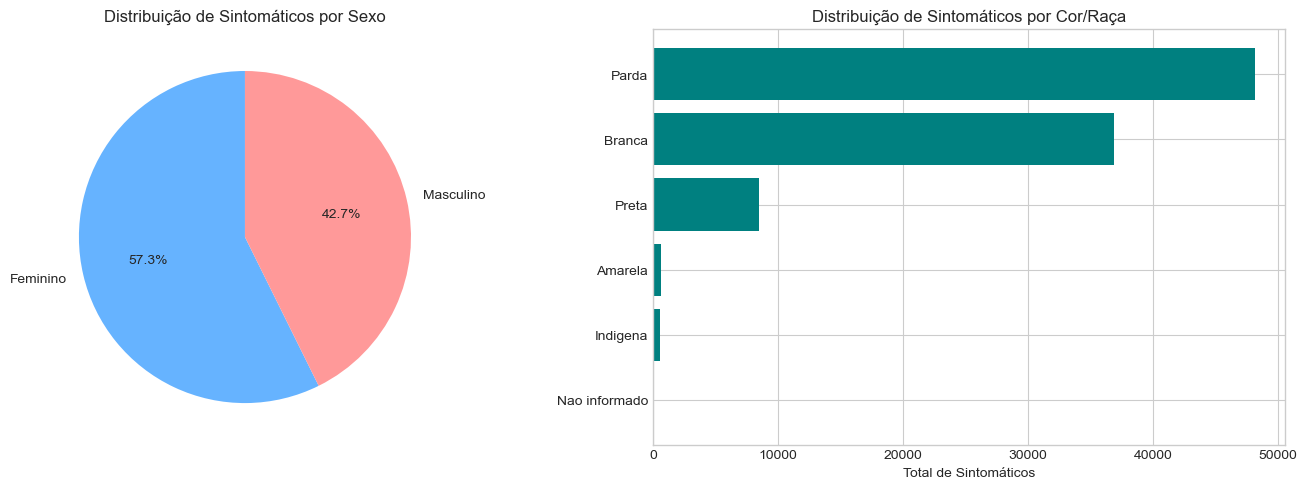

In [7]:
# Filtrar dados válidos
df_perfil_filtrado = df_perfil[
    (df_perfil['sexo_desc'] != 'Não informado') & 
    (df_perfil['cor_raca_desc'] != 'Não informado')
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Por sexo
sintomas_sexo = df_perfil_filtrado.groupby('sexo_desc')['total_sintomaticos'].sum().reset_index()
ax1 = axes[0]
ax1.pie(sintomas_sexo['total_sintomaticos'], labels=sintomas_sexo['sexo_desc'], 
        autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#ff9999'])
ax1.set_title('Distribuição de Sintomáticos por Sexo')

# Por cor/raça
sintomas_raca = df_perfil_filtrado.groupby('cor_raca_desc')['total_sintomaticos'].sum().reset_index()
sintomas_raca = sintomas_raca.sort_values('total_sintomaticos', ascending=True)
ax2 = axes[1]
ax2.barh(sintomas_raca['cor_raca_desc'], sintomas_raca['total_sintomaticos'], color='teal')
ax2.set_xlabel('Total de Sintomáticos')
ax2.set_title('Distribuição de Sintomáticos por Cor/Raça')

plt.tight_layout()
plt.savefig('../reports/04_perfil_demografico.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Taxa de Positividade

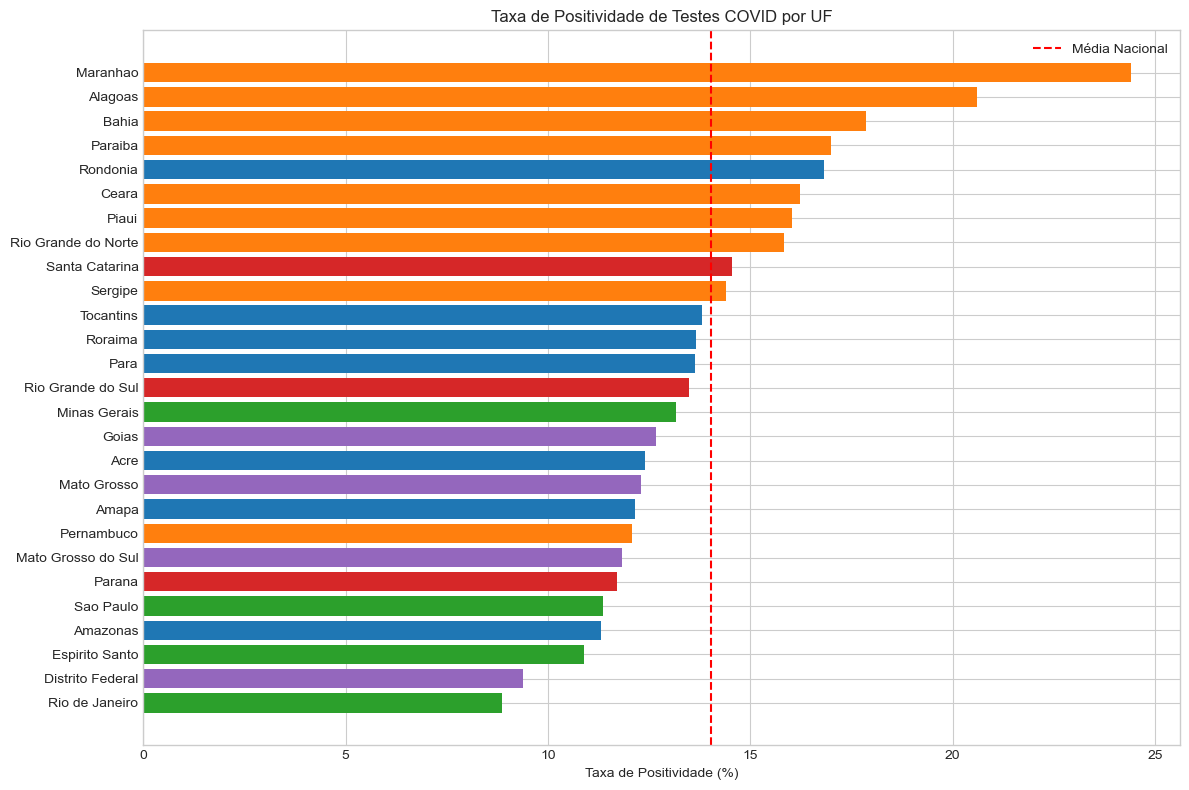

In [8]:
fig, ax = plt.subplots(figsize=(12, 8))

testes_ordenado = df_testes.sort_values('taxa_positividade', ascending=True)
colors = testes_ordenado['regiao'].map({
    'Norte': '#1f77b4',
    'Nordeste': '#ff7f0e',
    'Sudeste': '#2ca02c',
    'Sul': '#d62728',
    'Centro-Oeste': '#9467bd'
})
ax.barh(testes_ordenado['uf_nome'], testes_ordenado['taxa_positividade'], color=colors)
ax.set_xlabel('Taxa de Positividade (%)')
ax.set_title('Taxa de Positividade de Testes COVID por UF')
ax.axvline(x=testes_ordenado['taxa_positividade'].mean(), color='red', linestyle='--', label='Média Nacional')
ax.legend()

plt.tight_layout()
plt.savefig('../reports/05_taxa_positividade.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Resumo Estatístico

In [9]:
print("=" * 60)
print("RESUMO ESTATÍSTICO - PNAD COVID-19 (Set-Nov/2020)")
print("=" * 60)

# Totais
total_entrevistados = df_evolucao['total_entrevistados'].sum()
total_sintomaticos = df_evolucao['total_com_sintomas'].sum()
total_testados = df_evolucao['total_testados'].sum()
total_positivos = df_evolucao['total_positivos'].sum()
total_internados = df_evolucao['total_internados'].sum()

print(f"\n📊 TOTAIS DO PERÍODO:")
print(f"   Total de entrevistas: {total_entrevistados:,}")
print(f"   Com sintomas COVID: {total_sintomaticos:,} ({total_sintomaticos/total_entrevistados*100:.1f}%)")
print(f"   Testados: {total_testados:,} ({total_testados/total_entrevistados*100:.1f}%)")
print(f"   Positivos: {total_positivos:,}")
print(f"   Taxa de positividade: {total_positivos/total_testados*100:.1f}%")
print(f"   Internados: {total_internados:,}")

# Por região
print(f"\n📍 POR REGIÃO (% médio de sintomáticos):")
sintomas_regiao = df_sintomas_uf.groupby('regiao')['pct_sintomas_covid'].mean().sort_values(ascending=False)
for regiao, pct in sintomas_regiao.items():
    print(f"   {regiao}: {pct:.1f}%")

# Taxa de positividade por região
print(f"\n🧪 TAXA DE POSITIVIDADE POR REGIÃO:")
testes_regiao = df_testes.groupby('regiao').agg({
    'total_testados': 'sum',
    'total_positivos': 'sum'
})
testes_regiao['taxa'] = testes_regiao['total_positivos'] / testes_regiao['total_testados'] * 100
testes_regiao = testes_regiao.sort_values('taxa', ascending=False)
for regiao, row in testes_regiao.iterrows():
    print(f"   {regiao}: {row['taxa']:.1f}%")

print("\n" + "=" * 60)

RESUMO ESTATÍSTICO - PNAD COVID-19 (Set-Nov/2020)

📊 TOTAIS DO PERÍODO:
   Total de entrevistas: 1,149,197
   Com sintomas COVID: 23,633 (2.1%)
   Testados: 95,811 (8.3%)
   Positivos: 39,291
   Taxa de positividade: 41.0%
   Internados: 292

📍 POR REGIÃO (% médio de sintomáticos):
   Norte: 2.4%
   Centro-Oeste: 2.2%
   Sul: 2.0%
   Nordeste: 2.0%
   Sudeste: 1.9%

🧪 TAXA DE POSITIVIDADE POR REGIÃO:
   Nordeste: 16.6%
   Norte: 13.5%
   Sul: 13.3%
   Centro-Oeste: 11.7%
   Sudeste: 11.1%

